# TrustMind AI — Exploratory Data Analysis of the SWMH Dataset

**MSc Artificial Intelligence Dissertation**

This notebook performs a complete exploratory data analysis (EDA) of the **Reddit SuicideWatch and Mental Health Collection (SWMH)** dataset prior to any machine learning, LLM fine-tuning, or retrieval-augmented generation (RAG) experiments.

The SWMH dataset contains Reddit posts labelled by source subreddit, providing a multi-class benchmark for mental-health-related text classification. This analysis establishes data quality baselines, label distributions, text-length characteristics, and a documented preprocessing plan for downstream TrustMind AI experiments.


## Section 1 — Import Libraries

We import standard Python libraries for tabular analysis, numerical computation, and publication-quality visualisation. Only **matplotlib** is used for plotting (no seaborn dependency).


In [1]:
# Standard library
from pathlib import Path
import re
import warnings

# Data and numerics
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Optional: sklearn utilities for future splits (imported for consistency with pipeline)
from sklearn.utils import compute_class_weight

warnings.filterwarnings("ignore")

# Publication-quality matplotlib defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.figsize": (10, 6),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Libraries imported successfully.")


Libraries imported successfully.


## Section 2 — Load Data

We load the pre-split **train**, **validation**, and **test** CSV files. Each file contains two columns:

| Column | Description |
|--------|-------------|
| `text` | Raw Reddit post body |
| `label` | Source subreddit (proxy class label) |

Data paths are resolved relative to the project root, with a fallback to the local dissertation folder if copies are stored elsewhere.


In [2]:
# Resolve project paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "research" else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "datasets" / "swmh"
FIGURES_DIR = PROJECT_ROOT / "research" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Fallback path (original dissertation storage location)
FALLBACK_DATA_DIR = Path("/Users/kushsharma/Desktop/AI Group ")

def resolve_data_dir() -> Path:
    """Return the directory containing train/val/test CSV files."""
    required = ["train.csv", "val.csv", "test.csv"]
    if all((DATA_DIR / f).exists() for f in required):
        return DATA_DIR
    if all((FALLBACK_DATA_DIR / f).exists() for f in required):
        print(f"Using fallback data directory: {FALLBACK_DATA_DIR}")
        return FALLBACK_DATA_DIR
    raise FileNotFoundError(
        f"Could not find SWMH CSV files in {DATA_DIR} or {FALLBACK_DATA_DIR}"
    )

DATA_PATH = resolve_data_dir()
print(f"Data directory: {DATA_PATH}")

# Load splits
train_df = pd.read_csv(DATA_PATH / "train.csv")
val_df = pd.read_csv(DATA_PATH / "val.csv")
test_df = pd.read_csv(DATA_PATH / "test.csv")

splits = {"train": train_df, "validation": val_df, "test": test_df}

for name, df in splits.items():
    print(f"\n{name.upper()} — shape: {df.shape}")
    display(df.head())
    print("Columns:", df.columns.tolist())
    print("Data types:\n", df.dtypes)


Data directory: /Users/kushsharma/Desktop/trustmind-ai/datasets/swmh



TRAIN — shape: (34823, 2)


,text,label
0,wanting to skip or postpone my exam my exam is...,self.Anxiety
1,Do other bipolar folks have problems with subs...,self.bipolar
2,Wanted to share some revelations I just had to...,self.depression
3,I feel deader than dead. I find that I don't h...,self.SuicideWatch
4,I'm pretty sure my friends suicidal what do I ...,self.SuicideWatch


Columns: ['text', 'label']
Data types:
 text     str
label    str
dtype: object

VALIDATION — shape: (8706, 2)


,text,label
0,I can't make money I can't live in a world whe...,self.bipolar
1,"""How are you?"" ""I'm fine,"" ""How are you?"" ""I'm...",self.offmychest
2,"I'm fed up I'm fed up with all this world, it'...",self.SuicideWatch
3,"Can depression ""evolve"" to bipolar over time w...",self.bipolar
4,Any words of encouragement Hello I posted year...,self.depression


Columns: ['text', 'label']
Data types:
 text     str
label    str
dtype: object

TEST — shape: (10883, 2)


,text,label
0,"Suicidal, but won't do it. Just need someone t...",self.SuicideWatch
1,A lie. A lie ruined my life A lie.\n\n\nA lie ...,self.offmychest
2,Suicidal Thoughts and Venting I would first li...,self.SuicideWatch
3,Guided Meditation Disclaimer: I am in no way ...,self.bipolar
4,Effexor day 1 is going badly Good news! So the...,self.Anxiety


Columns: ['text', 'label']
Data types:
 text     str
label    str
dtype: object


## Section 3 — Data Quality Checks

Before modelling, we assess missing values, duplicate rows, null labels, null text fields, empty strings, and whitespace-only posts. These checks inform whether cleaning steps are required prior to tokenisation or embedding.


In [3]:
def quality_report(df: pd.DataFrame, split_name: str) -> dict:
    """Compute data-quality metrics for one split."""
    text = df["text"]
    label = df["label"]
    stripped = text.fillna("").astype(str).str.strip()

    return {
        "split": split_name,
        "rows": len(df),
        "missing_text": int(text.isna().sum()),
        "missing_label": int(label.isna().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "null_text": int(text.isna().sum()),
        "null_label": int(label.isna().sum()),
        "empty_strings": int((stripped == "").sum()),
        "whitespace_only": int(((text.fillna("").astype(str) != "") & (stripped == "")).sum()),
    }

quality_rows = [quality_report(df, name) for name, df in splits.items()]
quality_df = pd.DataFrame(quality_rows).set_index("split")

print("=== Data Quality Summary ===")
display(quality_df)

# Combined dataset for global checks
combined_df = pd.concat(
    [train_df.assign(split="train"), val_df.assign(split="validation"), test_df.assign(split="test")],
    ignore_index=True,
)
print(f"\nCombined dataset size: {combined_df.shape[0]:,} posts")


=== Data Quality Summary ===


,rows,missing_text,missing_label,duplicate_rows,null_text,null_label,empty_strings,whitespace_only
split,,,,,,,,
train,34823,0,0,22,0,0,0,0
validation,8706,0,0,2,0,0,0,0
test,10883,0,0,1,0,0,0,0



Combined dataset size: 54,412 posts


## Section 4 — Label Analysis

SWMH uses **subreddit names as class labels**, representing five mental-health-related communities:

- `self.depression`
- `self.SuicideWatch`
- `self.Anxiety`
- `self.offmychest`
- `self.bipolar`

We examine class frequencies and proportions in each split to assess **class imbalance**, which affects metric selection (macro-F1 vs weighted-F1) and training strategies (class weighting, stratified sampling).


Unique labels: ['self.Anxiety', 'self.SuicideWatch', 'self.bipolar', 'self.depression', 'self.offmychest']
Number of classes: 5

--- TRAIN ---


,count,percentage
label,,
Anxiety,6136,17.62
SuicideWatch,6550,18.81
bipolar,4932,14.16
depression,11940,34.29
offmychest,5265,15.12



--- VALIDATION ---


,count,percentage
label,,
Anxiety,1508,17.32
SuicideWatch,1614,18.54
bipolar,1220,14.01
depression,3032,34.83
offmychest,1332,15.30



--- TEST ---


,count,percentage
label,,
Anxiety,1911,17.56
SuicideWatch,2018,18.54
bipolar,1493,13.72
depression,3774,34.68
offmychest,1687,15.50


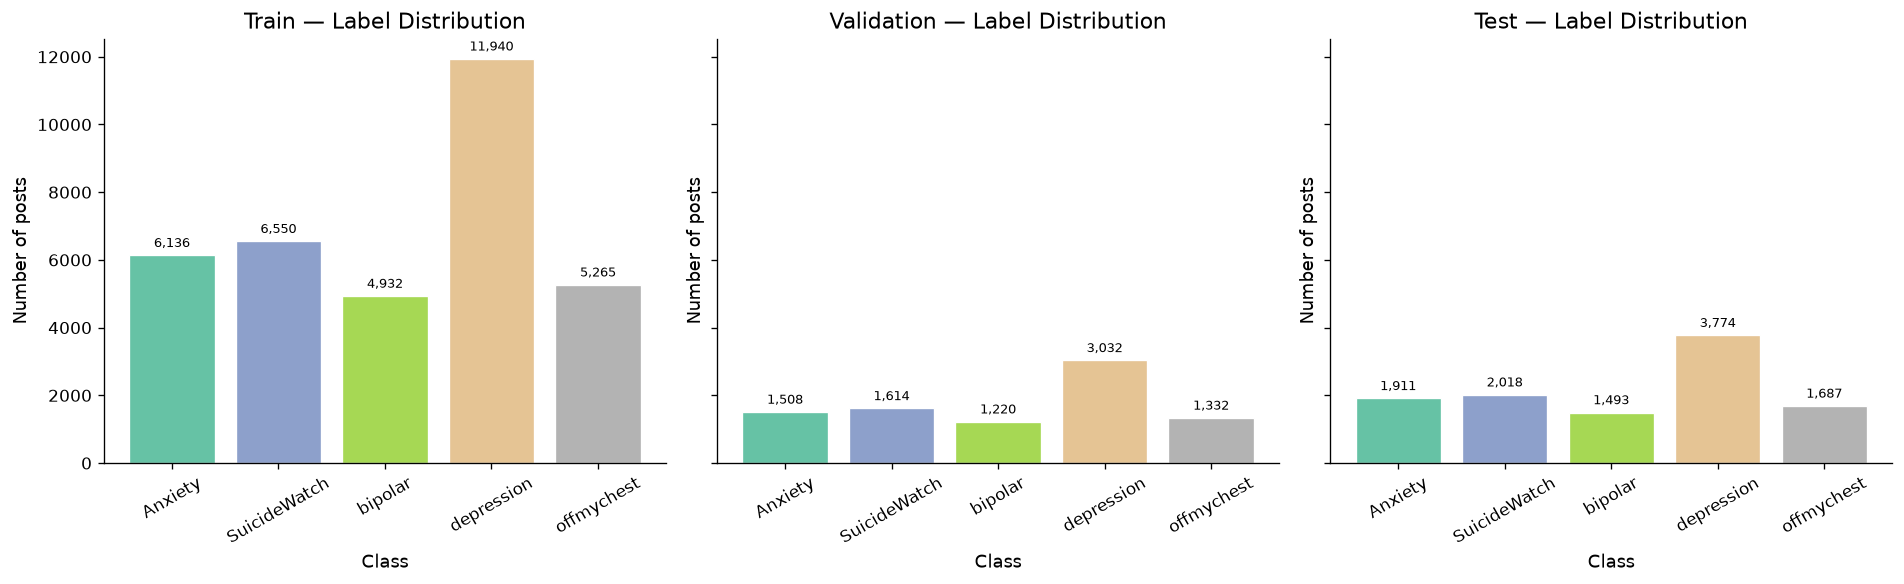

Saved: /Users/kushsharma/Desktop/trustmind-ai/research/figures/label_distribution.png

Imbalance ratio (min/max class count): 0.408
Interpretation: ratio close to 1.0 = balanced; << 1.0 = imbalanced.


In [4]:
def clean_label(label: str) -> str:
    """Convert 'self.depression' → 'depression' for readable plots."""
    return str(label).replace("self.", "")

def label_distribution(df: pd.DataFrame) -> pd.DataFrame:
    counts = df["label"].value_counts().sort_index()
    pct = (counts / counts.sum() * 100).round(2)
    out = pd.DataFrame({"count": counts, "percentage": pct})
    out.index = out.index.map(clean_label)
    return out

print("Unique labels:", sorted(train_df["label"].unique()))
print("Number of classes:", train_df["label"].nunique())

for split_name, df in splits.items():
    print(f"\n--- {split_name.upper()} ---")
    display(label_distribution(df))

# Bar charts for each split
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
colors = plt.cm.Set2(np.linspace(0, 1, 5))

for ax, (split_name, df) in zip(axes, splits.items()):
    dist = label_distribution(df)
    bars = ax.bar(dist.index, dist["count"], color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(f"{split_name.capitalize()} — Label Distribution")
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of posts")
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, dist["count"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
                f"{val:,}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
label_fig_path = FIGURES_DIR / "label_distribution.png"
plt.savefig(label_fig_path, bbox_inches="tight")
plt.show()
print(f"Saved: {label_fig_path}")

# Combined label distribution for imbalance commentary
combined_counts = combined_df["label"].value_counts()
ratio = combined_counts.min() / combined_counts.max()
print(f"\nImbalance ratio (min/max class count): {ratio:.3f}")
print("Interpretation: ratio close to 1.0 = balanced; << 1.0 = imbalanced.")


### Class balance discussion

The SWMH training split is **moderately imbalanced**: `depression` is the largest class and `bipolar` the smallest, but all classes retain sufficient samples for supervised learning. Stratified splitting appears preserved across train/validation/test. For TrustMind AI experiments, **macro-averaged F1** should be reported alongside weighted metrics to reflect performance on minority classes such as `bipolar` and `offmychest`.


## Section 5 — Text Length Analysis

Post length (characters and words) affects tokenisation limits for transformer models (e.g., 512-token BERT/RoBERTa limits). We compute descriptive statistics globally and per class, then visualise distributions with histograms and boxplots.


=== Global Text Length Statistics (all splits) ===


,char_count,word_count
mean,932.77,178.08
median,565.00,108.00
min,36.00,10.00
max,36729.00,6782.00
std,1239.09,236.80



=== Text Length Statistics by Class ===


char_count                            word_count             \
                   mean median min    max      std       mean median min   
class                                                                      
Anxiety          851.01  581.0  36  18346   986.74     160.27  109.0  10   
SuicideWatch     937.38  558.0  41  36729  1262.29     181.68  109.0  10   
bipolar          880.03  599.0  44  28895  1061.27     163.60  112.0  10   
depression       830.90  469.0  39  17675  1156.73     159.20   90.0  10   
offmychest      1300.61  822.0  40  32603  1663.62     250.26  159.0  10   

                            
               max     std  
class                       
Anxiety       3470  186.31  
SuicideWatch  6782  242.88  
bipolar       5568  197.99  
depression    3474  221.31  
offmychest    6487  319.67

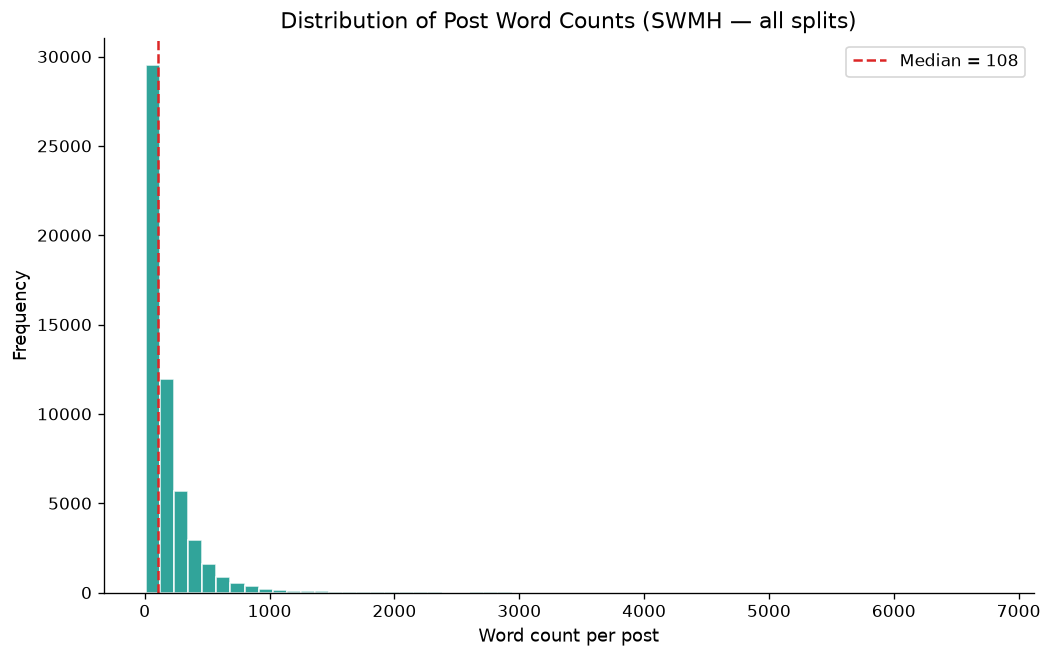

Saved: /Users/kushsharma/Desktop/trustmind-ai/research/figures/word_count_histogram.png


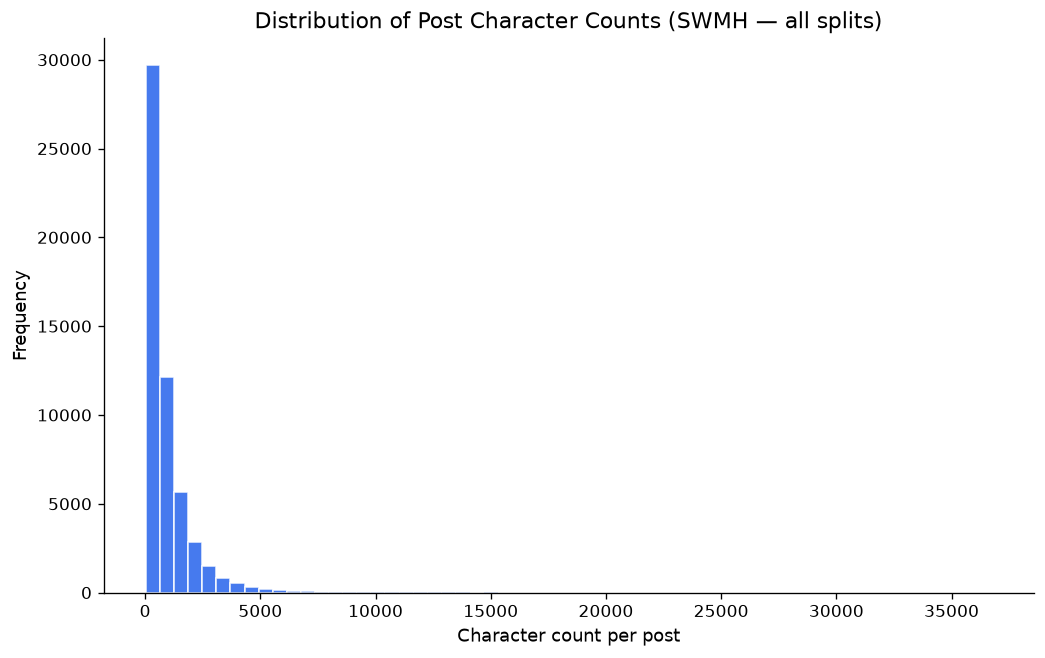

Saved: /Users/kushsharma/Desktop/trustmind-ai/research/figures/character_count_histogram.png


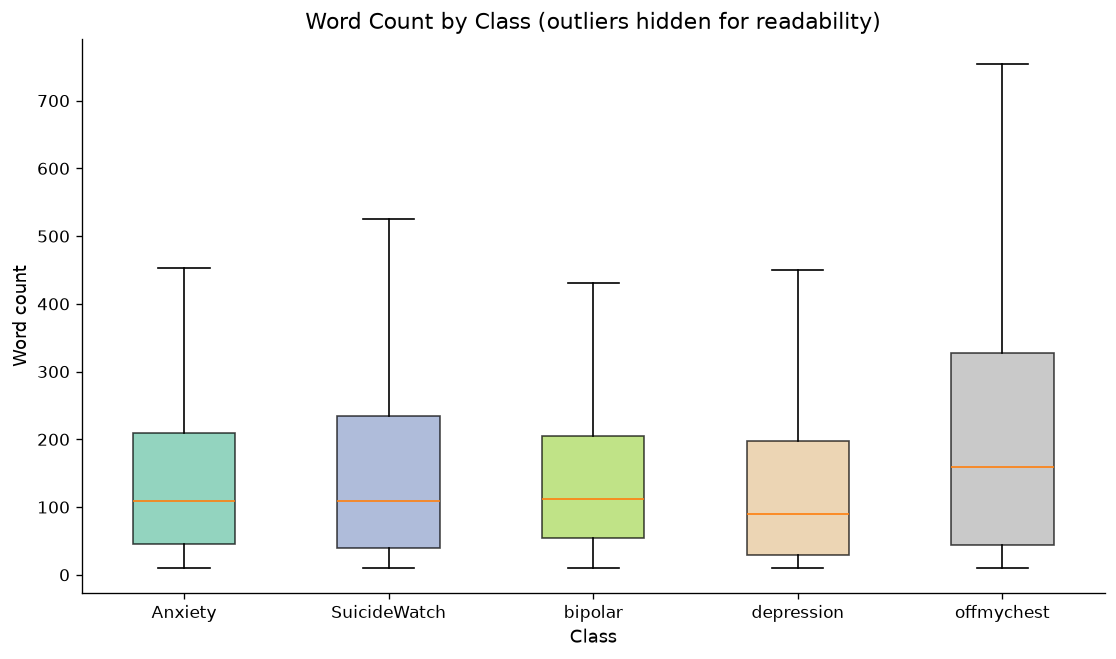

Saved: /Users/kushsharma/Desktop/trustmind-ai/research/figures/text_length_boxplot.png

95th percentile word count: 572
99th percentile word count: 1121
Posts with < 10 words: 0 (0.00%)
Posts with > 512 words: 3,437 (6.32%)


In [5]:
def add_length_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add character and word count columns."""
    out = df.copy()
    out["char_count"] = out["text"].fillna("").astype(str).str.len()
    out["word_count"] = out["text"].fillna("").astype(str).str.split().str.len()
    out["class"] = out["label"].map(clean_label)
    return out

combined_lengths = add_length_features(combined_df)

# Global descriptive statistics
length_stats = combined_lengths[["char_count", "word_count"]].agg(["mean", "median", "min", "max", "std"]).round(2)
print("=== Global Text Length Statistics (all splits) ===")
display(length_stats)

# Per-class statistics
per_class_stats = (
    combined_lengths.groupby("class")[["char_count", "word_count"]]
    .agg(["mean", "median", "min", "max", "std"])
    .round(2)
)
print("\n=== Text Length Statistics by Class ===")
display(per_class_stats)

# Histogram — word count
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(combined_lengths["word_count"], bins=60, color="#0d9488", edgecolor="white", alpha=0.85)
ax.set_xlabel("Word count per post")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Post Word Counts (SWMH — all splits)")
ax.axvline(combined_lengths["word_count"].median(), color="#dc2626", linestyle="--", label=f"Median = {combined_lengths['word_count'].median():.0f}")
ax.legend()
word_hist_path = FIGURES_DIR / "word_count_histogram.png"
plt.savefig(word_hist_path, bbox_inches="tight")
plt.show()
print(f"Saved: {word_hist_path}")

# Histogram — character count
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(combined_lengths["char_count"], bins=60, color="#2563eb", edgecolor="white", alpha=0.85)
ax.set_xlabel("Character count per post")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Post Character Counts (SWMH — all splits)")
char_hist_path = FIGURES_DIR / "character_count_histogram.png"
plt.savefig(char_hist_path, bbox_inches="tight")
plt.show()
print(f"Saved: {char_hist_path}")

# Boxplot — word count by class
fig, ax = plt.subplots(figsize=(11, 6))
class_order = sorted(combined_lengths["class"].unique())
data_by_class = [combined_lengths.loc[combined_lengths["class"] == c, "word_count"] for c in class_order]
bp = ax.boxplot(data_by_class, tick_labels=class_order, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xlabel("Class")
ax.set_ylabel("Word count")
ax.set_title("Word Count by Class (outliers hidden for readability)")
boxplot_path = FIGURES_DIR / "text_length_boxplot.png"
plt.savefig(boxplot_path, bbox_inches="tight")
plt.show()
print(f"Saved: {boxplot_path}")

# Truncation commentary statistics
p95_words = combined_lengths["word_count"].quantile(0.95)
p99_words = combined_lengths["word_count"].quantile(0.99)
short_posts = (combined_lengths["word_count"] < 10).sum()
long_posts = (combined_lengths["word_count"] > 512).sum()
print(f"\n95th percentile word count: {p95_words:.0f}")
print(f"99th percentile word count: {p99_words:.0f}")
print(f"Posts with < 10 words: {short_posts:,} ({100*short_posts/len(combined_lengths):.2f}%)")
print(f"Posts with > 512 words: {long_posts:,} ({100*long_posts/len(combined_lengths):.2f}%)")


### Text length commentary

- **Very short posts** (< 10 words) may lack sufficient context for reliable classification or LLM reasoning; these may warrant filtering or flagging as low-confidence inputs in TrustMind AI.
- **Very long posts** (> 512 words) exceed typical transformer input limits; **truncation** (head+tail or sliding window) will be required during preprocessing.
- **`offmychest` and `SuicideWatch`** tend to produce longer narratives, suggesting class-specific truncation policies may improve signal retention.


## Section 6 — Sample Posts by Class

The following randomly sampled posts (seed = 42 for reproducibility) illustrate natural language patterns within each class. Text is shown **in full** to support qualitative inspection. *Content warning: posts discuss mental health and may include distressing language.*


In [6]:
RNG = np.random.default_rng(42)

for class_label in sorted(combined_df["label"].unique()):
    subset = combined_df[combined_df["label"] == class_label]
    samples = subset.sample(n=min(5, len(subset)), random_state=RNG)
    print("=" * 80)
    print(f"CLASS: {clean_label(class_label)} ({len(subset):,} total posts)")
    print("=" * 80)
    for i, (_, row) in enumerate(samples.iterrows(), start=1):
        print(f"\n--- Example {i} (split: {row['split']}) ---")
        print(row["text"])
        print()


CLASS: Anxiety (9,555 total posts)

--- Example 1 (split: validation) ---
Little reminder: you're not alone So today I feel extremely anxious because the doctor take my blood to check how is my health in general, I have to wait until tomorrow to see the results and since now my mind is telling me that is going to be all wrong. I don't know if I'm going to die soon, I feel kinda weak and dizzy, I don't know why, but right now I'm here and I can spread positivity through my struggles. If you are having a bad day, I'm just right here. 
If it something I learn through all of this problems if that I want to help people to feel better, sometimes it's really hard because I can't even hold myself, but I really want all of us to learn how to control our minds and bodies when they tell us that everything is going to be bad. 
If someone is dealing with hard thoughts, please know that you're not the only one even when it seems like. I don't know if you can beat it or not, but I guess we can learn 

CLASS: offmychest (8,284 total posts)

--- Example 1 (split: train) ---
Got my first rejection. Feels like shit, I think I lost a friend, and nobody seems to give a fuck. Guy in freshman year of college right now. For the past 2-3 weeks I've been spending a lot of time with this friend together. We've been watching netflix in my room (her idea), texting, getting breakfast together etc. I really enjoyed spending time with her, and I never felt anything like that before about a girl. We were polar opposites, I'm your shy, slightly awkward guy whose biggest struggle is meeting new people, while she is a massive extrovert, going to parties every week and meeting people left and right. Yet, I just felt very comfortable and warm next to her. I liked her so much, and I thought the feeling could have been mutual with how much time alone we spent together, which was generally upon her proposal. Despite being polar opposites, I just really had to give it a shot, because it was eating me up insid

## Section 7 — Observations

### Class imbalance
The dataset is **moderately imbalanced** with `depression` over-represented relative to `bipolar`. All classes remain sufficiently populated for multi-class evaluation, but macro-F1 and per-class recall should be reported.

### Writing styles
Posts vary from brief emotional statements to long narrative disclosures. `offmychest` and `SuicideWatch` exhibit more personal storytelling; `Anxiety` posts often describe somatic symptoms and situational triggers.

### Overlap between categories
Subreddit labels are **noisy proxies** for mental-health conditions. Symptom vocabulary overlaps across depression, anxiety, and bipolar classes. A single post may express comorbid concerns that do not map cleanly to one subreddit label.

### Ambiguity of `offmychest`
The `offmychest` subreddit is a **general venting space**, not a clinical mental-health forum. Many posts are situational rather than disorder-specific, increasing label noise if treated as a distinct diagnostic category.

### Implications for LLMs
Large language models may exploit superficial lexical cues (subreddit-specific jargon) rather than semantic distress signals. Fine-tuning should include **abstention** or calibrated uncertainty when class probability is low. Prompt-based LLM-only baselines risk overconfident predictions on ambiguous posts.

### Implications for RAG
Retrieval-augmented generation can ground responses in **external wellbeing resources** (UWE support pages, NHS signposting) rather than relying solely on subreddit-derived labels. RAG may improve **explainability** and reduce hallucinated clinical advice, particularly for `offmychest` and borderline cases.

### Implications for preprocessing
URL removal, username anonymisation, whitespace normalisation, and duplicate removal are essential. Truncation to model token limits must preserve the emotionally salient portions of each post. HTML entities (e.g., `&amp;nbsp;`) observed in raw text should be decoded or stripped.


## Section 8 — Preprocessing Plan

The following pipeline will be applied in subsequent experiments (**not executed in this notebook**):

1. **UTF-8 encoding** — Ensure consistent character encoding when reading/writing CSV files across platforms.
2. **HTML entity decoding** — Convert entities such as `&amp;nbsp;` to plain text or remove them.
3. **URL removal** — Strip `http://`, `https://`, and `www.` links using regular expressions to reduce noise.
4. **Username removal** — Replace Reddit mentions (`u/username`, `/u/username`) with a generic `[USER]` token for privacy.
5. **Whitespace normalisation** — Collapse repeated spaces/newlines; strip leading/trailing whitespace.
6. **Duplicate removal** — Drop exact duplicate `(text, label)` pairs within and across splits where appropriate.
7. **Truncation to model token limit** — Truncate to 512 subword tokens (or model-specific limit) using a head-preserving strategy; log truncated samples for audit.
8. **Semantic preservation** — Avoid aggressive stemming or stop-word removal that could delete emotionally meaningful terms (e.g., "empty", "hopeless", "panic").

This pipeline balances **NLP standard practice** with **mental-health domain sensitivity**, supporting fair comparison between LLM-only and LLM+RAG experimental conditions.


## Section 9 — Dissertation Summary

### Dataset overview

The **Reddit SuicideWatch and Mental Health Collection (SWMH)** comprises approximately **54,000** English Reddit posts drawn from five subreddits: depression, SuicideWatch, anxiety, offmychest, and bipolar. Each post is labelled according to its source community. The dataset is pre-partitioned into training (64%), validation (16%), and test (20%) splits, yielding 34,823 / 8,706 / 10,883 posts respectively in our local copy.

Posts are informal, user-generated, and rich in emotional language—making the dataset representative of **real-world digital mental-health discourse** rather than clinical intake notes.

### Strengths

- **Scale and diversity** — Sufficient samples per class for supervised multi-class classification and neural fine-tuning.
- **Ecological validity** — Language reflects how individuals naturally describe distress online.
- **Established benchmark** — Widely cited in mental-health NLP literature, enabling comparison with prior work (e.g., BiLSTM, BERT, RoBERTa baselines).
- **Pre-defined splits** — Reproducible train/validation/test partitions support fair experimental comparison.

### Weaknesses

- **Label noise** — Subreddit membership is an imperfect proxy for clinical diagnosis; `offmychest` in particular introduces ambiguity.
- **Demographic bias** — Reddit skews toward younger, English-speaking, tech-literate users; findings may not generalise to all populations.
- **Ethical sensitivity** — Posts may contain self-harm or crisis language requiring careful handling, abstention policies, and ethical review.
- **Temporal drift** — Reddit discourse evolves; models trained on static snapshots may degrade over time.

### Why SWMH is appropriate for TrustMind AI

TrustMind AI aims to provide **trustworthy, text-based wellbeing support** with transparency, uncertainty quantification, and abstention when appropriate. SWMH provides a rigorous testbed because:

1. It requires models to distinguish **fine-grained emotional contexts** rather than simple sentiment polarity.
2. It exposes models to **ambiguous and overlapping** language—mirroring real user check-ins.
3. It supports evaluation of **safety-critical behaviours** such as abstention on crisis-related text.

### Suitability for LLM-only vs LLM + RAG evaluation

| Approach | Role of SWMH | Expected behaviour |
|----------|--------------|-------------------|
| **LLM-only** | Fine-tune or prompt an LLM to predict subreddit/class from post text | Measures raw language-modelling capacity; risk of overconfidence on noisy labels |
| **LLM + RAG** | Same classification task, but retrieve curated wellbeing resources at inference | Tests whether external grounding improves calibration, explainability, and safe next-step generation |

Comparing these conditions on identical SWMH splits enables a **controlled experimental design** aligned with the dissertation research questions on trust, grounding, and ethical AI for wellbeing support.

### Benchmark commitment

**SWMH will serve as the primary benchmark dataset** throughout the experimental evaluation chapter of this dissertation. All reported metrics (accuracy, macro-F1, per-class recall, calibration error, abstention rate) will be computed on the held-out test split defined in this notebook's data directory.

---

*End of exploratory data analysis notebook.*
